# Airline Overbooking with Dynamic Programming

This notebook solves the Project 2 airline overbooking problem end to end. It:

- solves the baseline dynamic program for hard coach overbooking caps from 5 to 20 seats,
- compares the best hard-cap rule to the flexible no-sale policy from the prompt,
- performs a local sensitivity analysis on ticket-sale probabilities,
- re-solves the problem under seasonal demand,
- simulates the seasonal policies forward 100,000 times, and
- saves report-ready figures and tables into `outputs/`.


In [100]:
# ── Imports and Paths ──────────────────────────────────────────────────────────

from pathlib import Path
from dataclasses import dataclass, replace
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from scipy.stats import binom
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['grid.alpha']     = 0.5
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['figure.titlesize']  = 16   
plt.rcParams['axes.titlesize']    = 13   
plt.rcParams['axes.labelsize']    = 11   
plt.rcParams['xtick.labelsize']   = 10   
plt.rcParams['ytick.labelsize']   = 10
plt.rcParams['legend.fontsize']   = 10
plt.rcParams['legend.title_fontsize'] = 11


PAL            = ['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600']
CLR_HARD     = PAL[0]
CLR_FLEX     = PAL[3]
COLORS       = {'Hard-cap': CLR_HARD, 'Flexible': CLR_FLEX}


OUTPUT_DIR = Path('outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TAB_DIR = OUTPUT_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# ── Core constants ──────────────────────────────────────────────────────────
DAYS = 365
BETA = 1 / (1 + 0.17 / 365)   # daily discount factor at 17% p.a.
COACH_CAPACITY = 100
FIRST_CAPACITY = 20
COACH_SHOW = 0.95              # show-up probability for coach
FIRST_SHOW  = 0.97             # show-up probability for first class
BUMP_COST   = 50               # cost to upgrade a coach passenger to first
DENIED_COST = 425              # cost to deny boarding
SIM_SEED = 20260310
SIM_N = 100_000

# ── Action dataclass ─────────────────────────────────────────────────────────
@dataclass(frozen=True)
class Action:
    name: str
    price: float
    prob: float

# Parts 1–2: all three coach fares, no no-sale option
COACH_ACTIONS_FULL = [
    Action('Coach $300', 300.0, 0.65),
    Action('Coach $325', 325.0, 0.45),
    Action('Coach $350', 350.0, 0.30),
]

# Part 3: per the prompt — 4 choices each day:
#   high price ($350), medium price ($325), low price ($300), and no sale.
# The airline can force demand to 0, with a hard cap of 130 total coach seats.
COACH_ACTIONS_FLEX = [
    Action('No coach sale',  0.0, 0.0),
    Action('Coach $300', 300.0, 0.65),
    Action('Coach $325', 325.0, 0.45),
    Action('Coach $350', 350.0, 0.30),
]

FIRST_ACTIONS = [
    Action('First $425', 425.0, 0.08),
    Action('First $500', 500.0, 0.04),
]


In [101]:
# ── Function Defs ──────────────────────────────────────────────────────────

def build_terminal_costs(max_coach: int = 130, max_first: int = 20) -> np.ndarray:
    """
    Terminal value at t=0 (departure day): E[overbooking cost] for every possible (coach_sold, first_sold) state. 
    Computed once via the binomial show-up distribution and stored as a lookup table for all DP runs.
    Entries where c <= COACH_CAPACITY are zero — no overflow possible.
    """
    costs = np.zeros((max_coach + 1, max_first + 1))
    coach_pmfs = [binom.pmf(np.arange(c + 1), c, COACH_SHOW) for c in range(max_coach + 1)]
    first_pmfs = [binom.pmf(np.arange(f + 1), f, FIRST_SHOW) for f in range(max_first + 1)]
    for c in range(max_coach + 1):
        if c <= COACH_CAPACITY:
            continue
        c_show = np.arange(c + 1)[:, None]
        overflow = np.maximum(c_show - COACH_CAPACITY, 0)
        coach_prob = coach_pmfs[c][:, None]
        for f in range(max_first + 1):
            f_show = np.arange(f + 1)[None, :]
            first_prob = first_pmfs[f][None, :]
            spare_first = np.maximum(FIRST_CAPACITY - f_show, 0)
            bumped = np.minimum(overflow, spare_first)
            denied = np.maximum(overflow - spare_first, 0)
            costs[c, f] = np.sum(coach_prob * first_prob * (BUMP_COST * bumped + DENIED_COST * denied))
    return costs

TERM_COST = build_terminal_costs()


def pad_value_grid(values: np.ndarray) -> np.ndarray:
    """
    Extends V by one row/col, repeating the boundary values.
    This lets the vectorized Bellman update use V[nc+1, nf] safely:
    when nc == coach_limit (capacity hit), nxt[nc+1] == nxt[nc],
    so "selling a ticket" when full correctly leaves value unchanged.
    """
    padded = np.empty((values.shape[0] + 1, values.shape[1] + 1))
    padded[:-1, :-1] = values
    padded[-1, :-1] = values[-1, :]
    padded[:-1, -1] = values[:, -1]
    padded[-1, -1] = values[-1, -1]
    return padded


def solve_dp(coach_limit: int, coach_actions: list[Action], *, seasonality: bool = False) -> dict:
    """
    Backward induction over t = 1..DAYS.
    Bellman equation:
      V_t(nc, nf) = max_{a_c, a_f} {
          p_c * price_c + p_f * price_f
          + β * E[V_{t-1}(nc', nf')]
      }
    Terminal condition: V_0(nc, nf) = -E[overbooking cost | nc, nf]
    State: (nc, nf) = (coach tickets sold, FC tickets sold); t = days remaining
    """
    values = -TERM_COST[: coach_limit + 1, : FIRST_CAPACITY + 1].copy()
    coach_policy = np.full((DAYS + 1, coach_limit + 1, FIRST_CAPACITY + 1), -1, dtype=np.int8)
    first_policy = np.full((DAYS + 1, coach_limit + 1, FIRST_CAPACITY + 1), -1, dtype=np.int8)

    c_grid = np.arange(coach_limit + 1)[:, None]
    f_grid = np.arange(FIRST_CAPACITY + 1)[None, :]
    coach_open = c_grid < coach_limit
    first_open = f_grid < FIRST_CAPACITY
    first_sold_out = f_grid >= FIRST_CAPACITY

    for days_remaining in range(1, DAYS + 1):
        # day_index is the calendar booking day (1 = first day on sale, 365 = day before departure).
        day_index = DAYS - days_remaining + 1
        multiplier = 0.75 + day_index / 730 if seasonality else 1.0
        nxt = pad_value_grid(values)
        stay = nxt[:-1, :-1]
        coach_only = nxt[1:, :-1]
        first_only = nxt[:-1, 1:]
        both = nxt[1:, 1:]

        best = None
        best_c = None
        best_f = None
        for ci, c_action in enumerate(coach_actions):
            coach_prob = np.where(coach_open, c_action.prob * multiplier, 0.0)
            if c_action.prob > 0:
                coach_prob = np.where(
                    first_sold_out & coach_open,
                    np.minimum((c_action.prob + 0.04) * multiplier, 1.0),
                    coach_prob,
                )
            for fi, f_action in enumerate(FIRST_ACTIONS):
                first_prob = np.where(first_open, f_action.prob * multiplier, 0.0)
                cand = (
                    coach_prob * c_action.price
                    + first_prob * f_action.price
                    + BETA
                    * (
                        (1 - coach_prob) * (1 - first_prob) * stay
                        + coach_prob * (1 - first_prob) * coach_only
                        + (1 - coach_prob) * first_prob * first_only
                        + coach_prob * first_prob * both
                    )
                )
                if best is None:
                    best = cand
                    best_c = np.full(cand.shape, ci, dtype=np.int8)
                    best_f = np.full(cand.shape, fi, dtype=np.int8)
                else:
                    better = cand > best + 1e-12
                    best = np.where(better, cand, best)
                    best_c = np.where(better, ci, best_c)
                    best_f = np.where(better, fi, best_f)
        values = best
        coach_policy[days_remaining] = best_c
        first_policy[days_remaining] = best_f

    return {
        'value_grid': values,
        'coach_policy': coach_policy,
        'first_policy': first_policy,
        'initial_value': float(values[0, 0]),
        'coach_limit': coach_limit,
        'coach_actions': coach_actions,
        'seasonality': seasonality,
    }


def simulate_policy(solution: dict, *, n_sim: int = 100_000, seed: int = 0) -> dict:
    coach_limit = solution['coach_limit']
    coach_actions = solution['coach_actions']
    coach_policy = solution['coach_policy']
    first_policy = solution['first_policy']
    seasonality = solution['seasonality']

    rng = np.random.default_rng(seed)
    coach_prices = np.array([a.price for a in coach_actions])
    coach_probs = np.array([a.prob for a in coach_actions])
    first_prices = np.array([a.price for a in FIRST_ACTIONS])
    first_probs = np.array([a.prob for a in FIRST_ACTIONS])
    coach_none = coach_probs == 0

    coach_sold = np.zeros(n_sim, dtype=np.int16)
    first_sold = np.zeros(n_sim, dtype=np.int16)
    discounted_profit = np.zeros(n_sim)
    stop_day = np.full(n_sim, np.nan)
    discount = BETA ** np.arange(DAYS)

    for days_remaining in range(DAYS, 0, -1):
        day_index = DAYS - days_remaining + 1
        multiplier = 0.75 + day_index / 730 if seasonality else 1.0
        ci = coach_policy[days_remaining, coach_sold, first_sold]
        fi = first_policy[days_remaining, coach_sold, first_sold]

        pc = np.where(coach_sold < coach_limit, coach_probs[ci] * multiplier, 0.0)
        pc = np.where(
            (coach_probs[ci] > 0) & (coach_sold < coach_limit) & (first_sold >= FIRST_CAPACITY),
            np.minimum((coach_probs[ci] + 0.04) * multiplier, 1.0),
            pc,
        )
        pf = np.where(first_sold < FIRST_CAPACITY, first_probs[fi] * multiplier, 0.0)

        newly_closed = np.isnan(stop_day) & coach_none[ci]
        stop_day[newly_closed] = day_index

        coach_sale = rng.random(n_sim) < pc
        first_sale = rng.random(n_sim) < pf
        discounted_profit += discount[day_index - 1] * (coach_sale * coach_prices[ci] + first_sale * first_prices[fi])
        coach_sold += coach_sale.astype(np.int16)
        first_sold += first_sale.astype(np.int16)

    coach_show = rng.binomial(coach_sold, COACH_SHOW)
    first_show = rng.binomial(first_sold, FIRST_SHOW)
    overflow = np.maximum(coach_show - COACH_CAPACITY, 0)
    spare = np.maximum(FIRST_CAPACITY - first_show, 0)
    bumped = np.minimum(overflow, spare)
    denied = np.maximum(overflow - spare, 0)
    costs = BUMP_COST * bumped + DENIED_COST * denied

    # Overbooking costs realized at departure (one step beyond the last selling day),so they are discounted by β^365
    discounted_profit -= (BETA ** DAYS) * costs

    summary = {
        'Exact DP value': solution['initial_value'],
        'Simulated mean discounted profit': float(discounted_profit.mean()),
        'Profit volatility (std)': float(discounted_profit.std(ddof=1)),
        '5th percentile profit': float(np.quantile(discounted_profit, 0.05)),
        'Median profit': float(np.quantile(discounted_profit, 0.50)),
        '95th percentile profit': float(np.quantile(discounted_profit, 0.95)),
        'Mean overbooking cost': float(costs.mean()),
        'Mean coach tickets sold': float(coach_sold.mean()),
        'Mean first-class tickets sold': float(first_sold.mean()),
        'Probability coach is oversold in bookings': float((coach_sold > COACH_CAPACITY).mean()),
        'Probability realized coach overflow occurs': float((overflow > 0).mean()),
        'Probability at least one passenger is denied boarding': float((denied > 0).mean()),
        'Mean passengers upgraded to first class': float(bumped.mean()),
        'Mean passengers denied boarding': float(denied.mean()),
        'Share of paths where no-sale action is used': float(np.isfinite(stop_day).mean()),
        'Average first no-sale day': float(np.nanmean(stop_day)) if np.isfinite(stop_day).any() else np.nan,
    }
    return {
        'summary': summary,
        'discounted_profit': discounted_profit,
        'stop_day': stop_day,
    }


def evaluate_sensitivity(coach_limit: int, coach_actions: list[Action], coach_delta_grid, first_delta_grid) -> pd.DataFrame:
    records = []
    for coach_delta in coach_delta_grid:
        adjusted_coach = [
            replace(action, prob=max(0.0, min(1.0, action.prob + coach_delta))) if action.prob > 0 else action
            for action in coach_actions
        ]
        for first_delta in first_delta_grid:
            adjusted_first = [
                replace(action, prob=max(0.0, min(1.0, action.prob + first_delta)))
                for action in FIRST_ACTIONS
            ]
            values = -TERM_COST[: coach_limit + 1, : FIRST_CAPACITY + 1].copy()
            c_grid = np.arange(coach_limit + 1)[:, None]
            f_grid = np.arange(FIRST_CAPACITY + 1)[None, :]
            coach_open = c_grid < coach_limit
            first_open = f_grid < FIRST_CAPACITY
            first_sold_out = f_grid >= FIRST_CAPACITY
            for _ in range(1, DAYS + 1):
                nxt = pad_value_grid(values)
                stay = nxt[:-1, :-1]
                coach_only = nxt[1:, :-1]
                first_only = nxt[:-1, 1:]
                both = nxt[1:, 1:]
                best = None
                for c_action in adjusted_coach:
                    pc = np.where(coach_open, c_action.prob, 0.0)
                    if c_action.prob > 0:
                        pc = np.where(first_sold_out & coach_open, np.minimum(c_action.prob + 0.04, 1.0), pc)
                    for f_action in adjusted_first:
                        pf = np.where(first_open, f_action.prob, 0.0)
                        cand = (
                            pc * c_action.price
                            + pf * f_action.price
                            + BETA
                            * (
                                (1 - pc) * (1 - pf) * stay
                                + pc * (1 - pf) * coach_only
                                + (1 - pc) * pf * first_only
                                + pc * pf * both
                            )
                        )
                        best = cand if best is None else np.maximum(best, cand)
                values = best
            records.append({'coach_delta': coach_delta, 'first_delta': first_delta, 'expected_profit': float(values[0, 0])})
    return pd.DataFrame(records)


## Parts 1 and 2: hard-cap overbooking search

The first task is to solve the problem for a 5-seat coach oversell allowance, then repeat the dynamic program for coach oversell levels 6 through 20 and identify the best hard cap.

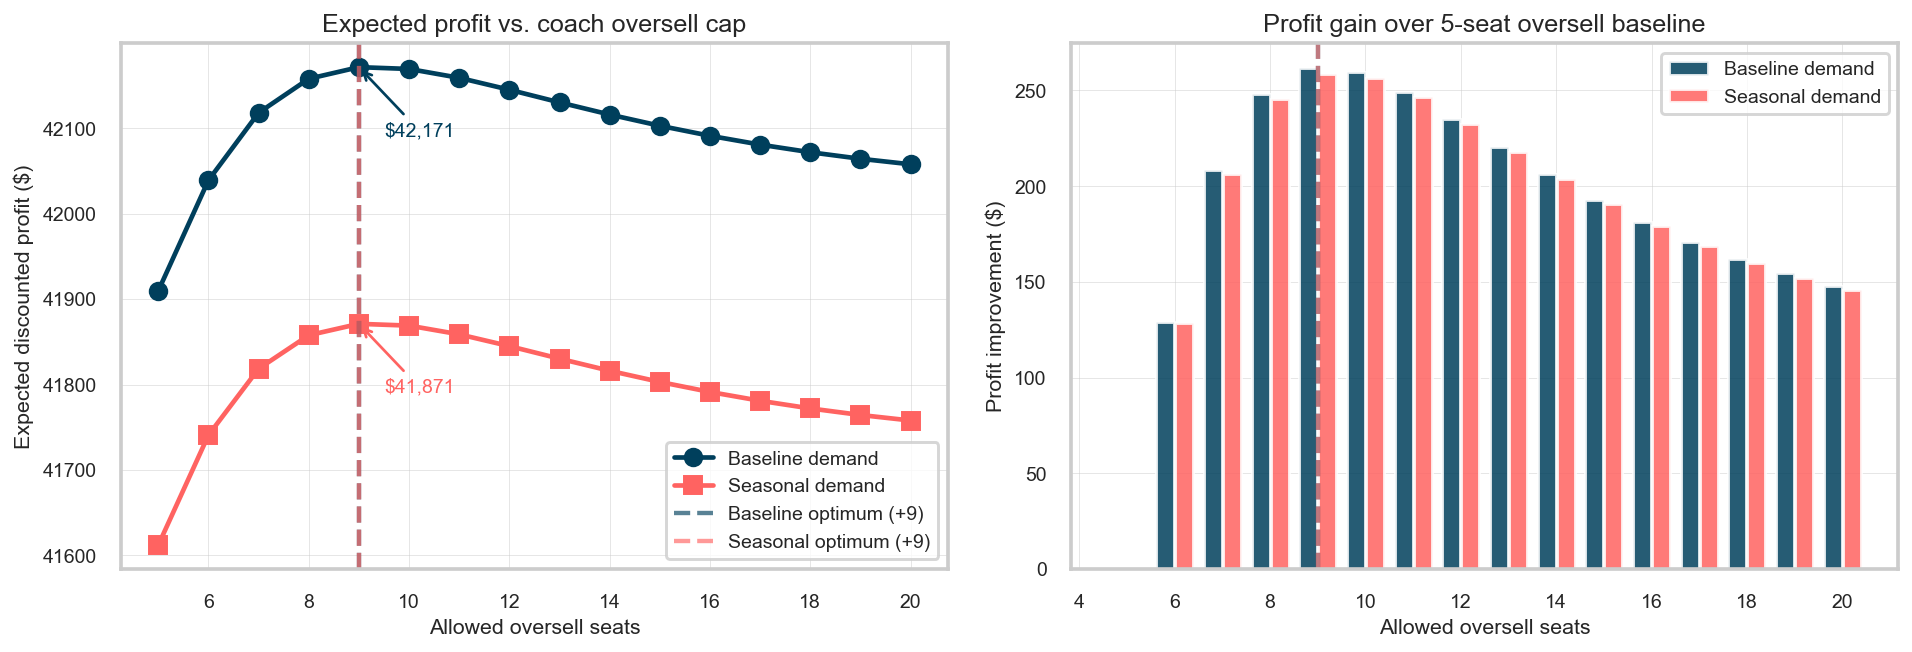

**Step 1 answer (5-seat oversell):** $41,909.75

**Best baseline hard cap:** oversell coach by **9** seats — profit $42,171.35

**Best seasonal hard cap:** oversell coach by **9** seats — profit $41,871.01

,oversell_limit,expected_profit
0,5,41909.75
1,6,42039.02
2,7,42117.95
3,8,42157.77
4,9,42171.35
5,10,42169.24
6,11,42158.86
7,12,42144.91
8,13,42130.13
9,14,42115.88


In [102]:
# Solve DP for all oversell caps (baseline and seasonal)
base_hard_df = pd.DataFrame([
    {'oversell_limit': k, 'expected_profit': solve_dp(100 + k, COACH_ACTIONS_FULL, seasonality=False)['initial_value']}
    for k in range(5, 21)
])
seasonal_hard_df = pd.DataFrame([
    {'oversell_limit': k, 'expected_profit': solve_dp(100 + k, COACH_ACTIONS_FULL, seasonality=True)['initial_value']}
    for k in range(5, 21)
])

base_hard_df.to_csv(TAB_DIR / 'baseline_hard_cap_search.csv', index=False)
seasonal_hard_df.to_csv(TAB_DIR / 'seasonal_hard_cap_search.csv', index=False)

step1_profit    = float(base_hard_df.loc[base_hard_df['oversell_limit'] == 5, 'expected_profit'].iloc[0])
base_best_k     = int(base_hard_df.loc[base_hard_df['expected_profit'].idxmax(),    'oversell_limit'])
seasonal_best_k = int(seasonal_hard_df.loc[seasonal_hard_df['expected_profit'].idxmax(), 'oversell_limit'])

# ── Visual 1: expected profit vs. oversell limit ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(base_hard_df['oversell_limit'],     base_hard_df['expected_profit'],
        marker='o', linewidth=2.4, label='Baseline demand', color=CLR_HARD)
ax.plot(seasonal_hard_df['oversell_limit'], seasonal_hard_df['expected_profit'],
        marker='s', linewidth=2.4, label='Seasonal demand',  color=CLR_FLEX)
ax.axvline(base_best_k,     color=CLR_HARD, linestyle='--', alpha=0.65, label=f'Baseline optimum (+{base_best_k})')
ax.axvline(seasonal_best_k, color=CLR_FLEX, linestyle='--', alpha=0.65, label=f'Seasonal optimum (+{seasonal_best_k})')

# annotate optimal points
for df, k, col in [(base_hard_df, base_best_k, CLR_HARD), (seasonal_hard_df, seasonal_best_k, CLR_FLEX)]:
    best_val = df.loc[df['oversell_limit'] == k, 'expected_profit'].iloc[0]
    ax.annotate(f'${best_val:,.0f}', xy=(k, best_val),
                xytext=(k + 0.5, best_val - 80),
                fontsize=10, color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=1.4))

ax.set_title('Expected profit vs. coach oversell cap')
ax.set_xlabel('Allowed oversell seats')
ax.set_ylabel('Expected discounted profit ($)')
ax.legend(fontsize=10, frameon=True)

# ── Visual 2: profit improvement relative to 5-seat baseline ─────────────────
ax2 = axes[1]
base_5    = step1_profit
gain_base = base_hard_df['expected_profit'] - base_5
gain_seas = seasonal_hard_df['expected_profit'] - seasonal_hard_df.loc[
    seasonal_hard_df['oversell_limit'] == 5, 'expected_profit'].iloc[0]

ax2.bar(base_hard_df['oversell_limit'] - 0.2, gain_base, width=0.38,
        label='Baseline demand', color=CLR_HARD, alpha=0.85)
ax2.bar(seasonal_hard_df['oversell_limit'] + 0.2, gain_seas, width=0.38,
        label='Seasonal demand', color=CLR_FLEX, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(base_best_k,     color=CLR_HARD, linestyle='--', alpha=0.55)
ax2.axvline(seasonal_best_k, color=CLR_FLEX, linestyle='--', alpha=0.55)
ax2.set_title('Profit gain over 5-seat oversell baseline')
ax2.set_xlabel('Allowed oversell seats')
ax2.set_ylabel('Profit improvement ($)')
ax2.legend(fontsize=10, frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / 'value_by_cap.png')
plt.show()

base_hard_df['expected_profit']     = base_hard_df['expected_profit'].round(2)
seasonal_hard_df['expected_profit'] = seasonal_hard_df['expected_profit'].round(2)
display(Markdown(f"**Step 1 answer (5-seat oversell):** ${step1_profit:,.2f}"))
display(Markdown(f"**Best baseline hard cap:** oversell coach by **{base_best_k}** seats — profit ${base_hard_df['expected_profit'].max():,.2f}"))
display(Markdown(f"**Best seasonal hard cap:** oversell coach by **{seasonal_best_k}** seats — profit ${seasonal_hard_df['expected_profit'].max():,.2f}"))
display(base_hard_df)


## Part 3: flexible no-sale policy

The prompt specifies **4 choices** for coach each day: high price ($350), medium price ($325), low price ($300), and **no sale** — the airline can force demand to zero on any given day. First-class retains its original 2 price options. The coach hard cap is raised to 130 seats, but the airline can now dynamically shut off sales rather than waiting for the cap to bind.

`COACH_ACTIONS_FLEX = {No coach sale, $300, $325, $350}` — this is the exact set described in the prompt.


,policy,Expected profit
0,Hard cap (coach limit = 109),"$42,171.35"
1,Flexible no-sale (4 choices: $300 / $325 / $35...,"$42,177.14"


Flexible no-sale policy: **$42,177.14** — **$5.79** above the best hard-cap rule.

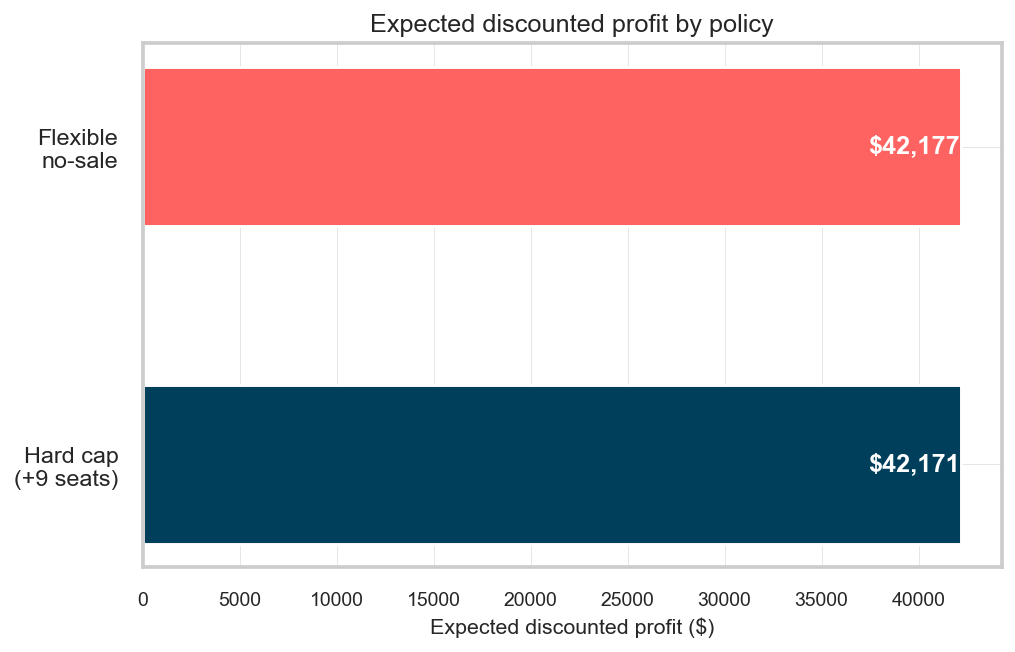

---

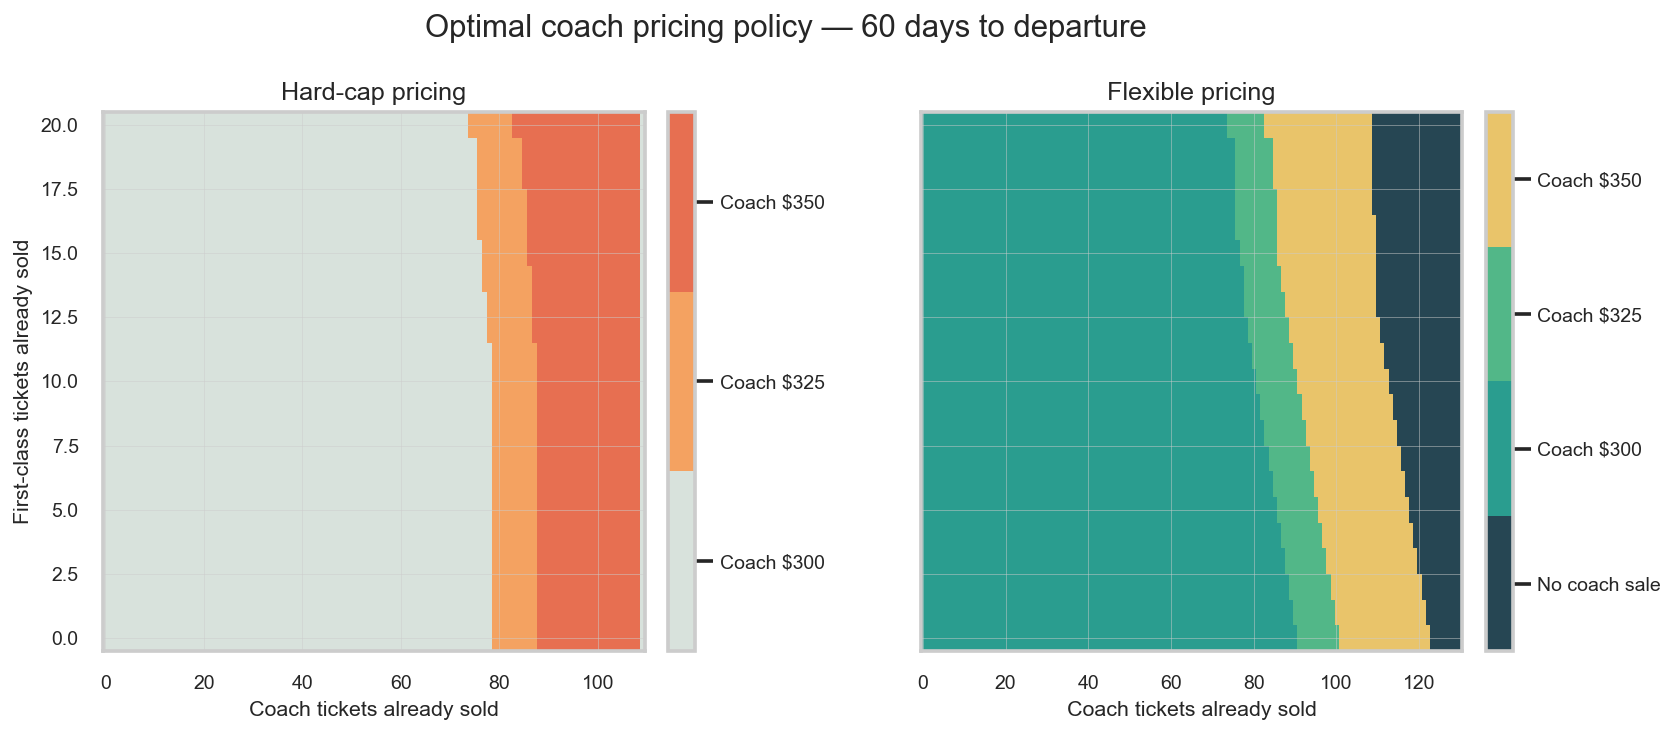

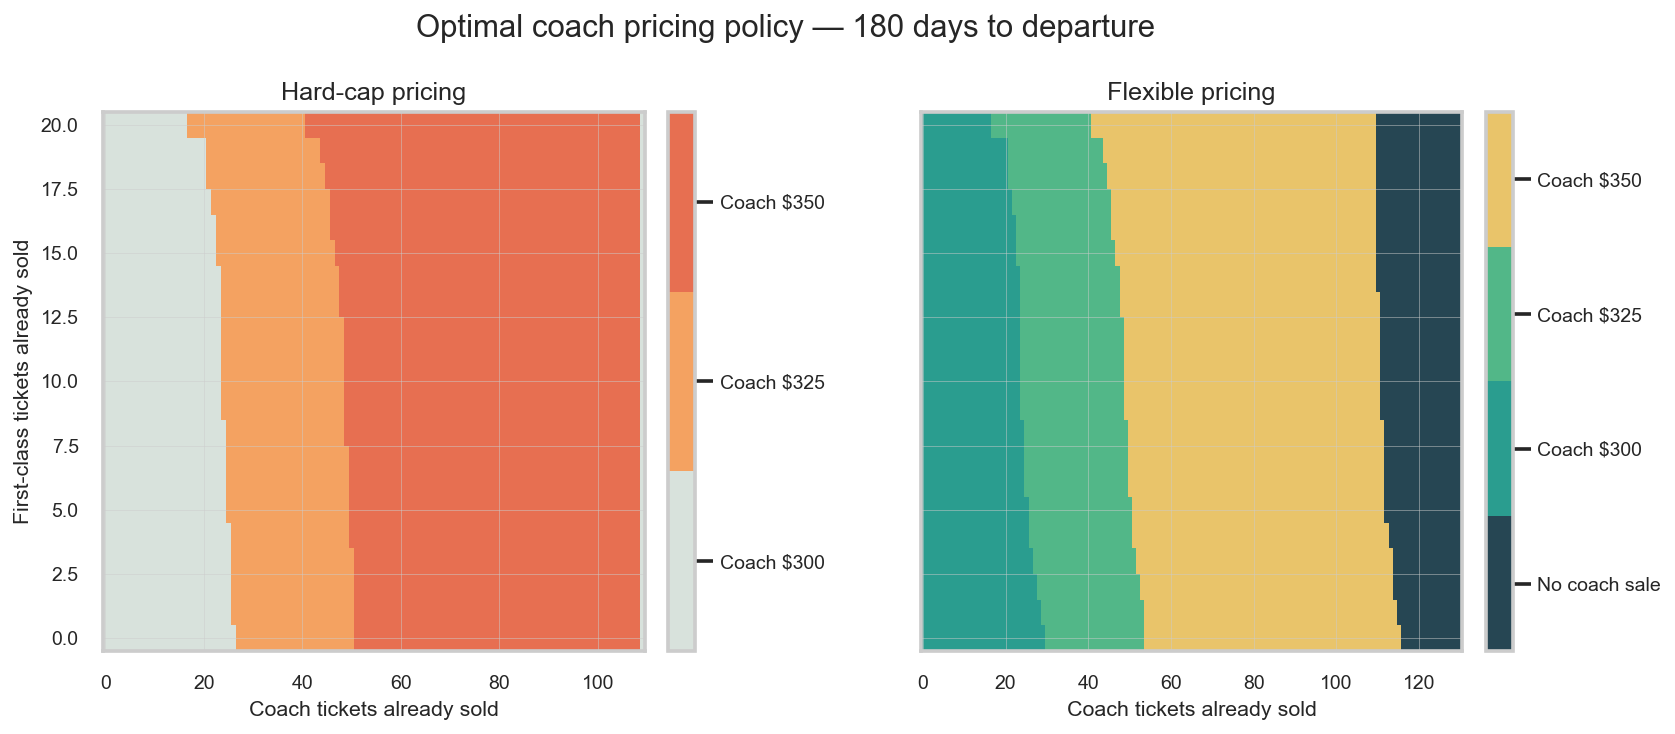

In [103]:
# Solve both policies
base_best_hard = solve_dp(100 + base_best_k, COACH_ACTIONS_FULL, seasonality=False)
base_flex      = solve_dp(130,                COACH_ACTIONS_FLEX, seasonality=False)

comparison_df = pd.DataFrame([
    {
        'policy': f'Hard cap (coach limit = {100 + base_best_k})',
        'expected_profit': base_best_hard['initial_value'],
    },
    {
        'policy': 'Flexible no-sale (4 choices: $300 / $325 / $350 / no sale)',
        'expected_profit': base_flex['initial_value'],
    },
])
comparison_df.to_csv(TAB_DIR / 'policy_comparison.csv', index=False)
comparison_df['expected_profit_fmt'] = comparison_df['expected_profit'].map('${:,.2f}'.format)
display(comparison_df[['policy', 'expected_profit_fmt']].rename(columns={'expected_profit_fmt': 'Expected profit'}))

diff = base_flex['initial_value'] - base_best_hard['initial_value']
sign = 'above' if diff >= 0 else 'below'
display(Markdown(
    f"Flexible no-sale policy: **${base_flex['initial_value']:,.2f}** — "
    f"**${abs(diff):,.2f}** {sign} the best hard-cap rule."
))

# ── Visual 1: bar chart of expected profit by policy ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [CLR_HARD, CLR_FLEX]
bars = axes[0].barh(
    [f'Hard cap\n(+{base_best_k} seats)', 'Flexible\nno-sale'],
    [base_best_hard['initial_value'], base_flex['initial_value']],
    color=colors, edgecolor='white', height=0.5,
)
for bar, val in zip(bars, [base_best_hard['initial_value'], base_flex['initial_value']]):
    axes[0].text(bar.get_width() - 30, bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}', va='center', ha='right', color='white', fontweight='bold', fontsize=13)
axes[0].set_title('Expected discounted profit by policy')
axes[0].set_xlabel('Expected discounted profit ($)')

lo = min(base_best_hard['initial_value'], base_flex['initial_value'])
hi = max(base_best_hard['initial_value'], base_flex['initial_value'])
ax.set_xlim(lo * 0.995, hi * 1.005)

axes[0].tick_params(axis='y', labelsize=12)

# ── Visual 2: policy heatmaps at two time horizons ───────────────────────────

fig.delaxes(axes[1])  # remove empty right axis

fig.tight_layout()
fig.savefig(FIG_DIR / 'policy_comparison_bar.png')
plt.show()

display(Markdown("---"))

# ── Visual 3: policy heatmaps at two time horizons (60 and 180 days left) ───
for policy_day in [60, 180]:
    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    fig2.subplots_adjust(wspace = 0.38)

    cmap_hard = ListedColormap(['#d8e2dc', '#f4a261', '#e76f51'])
    cmap_flex = ListedColormap(['#264653', '#2a9d8f', '#52b788', '#e9c46a'])

    im0 = axes2[0].imshow(
        base_best_hard['coach_policy'][policy_day].T,
        origin='lower', aspect='auto',
        cmap=cmap_hard, vmin=-0.5, vmax=2.5,
    )
    axes2[0].set_title(f'Hard-cap pricing')
    axes2[0].set_xlabel('Coach tickets already sold')
    axes2[0].set_ylabel('First-class tickets already sold')
    cb0 = fig2.colorbar(im0, ax=axes2[0], ticks=[0, 1, 2], fraction=0.046, pad=0.04)
    cb0.ax.set_yticklabels([a.name for a in COACH_ACTIONS_FULL])

    im1 = axes2[1].imshow(
        base_flex['coach_policy'][policy_day].T,
        origin='lower', aspect='auto',
        cmap=cmap_flex, vmin=-0.5, vmax=3.5,
    )
    axes2[1].set_title(f'Flexible pricing')
    axes2[1].set_xlabel('Coach tickets already sold')
    cb1 = fig2.colorbar(im1, ax=axes2[1], ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
    cb1.ax.set_yticklabels([a.name for a in COACH_ACTIONS_FLEX])

    fig2.suptitle(f'Optimal coach pricing policy — {policy_day} days to departure', fontsize=16, y=1.02)
    fig2.savefig(FIG_DIR / f'policy_maps_day{policy_day}.png')
    plt.show()


## Part 4: sensitivity analysis

I perturb coach sale probabilities by up to plus/minus 5 percentage points and first-class sale probabilities by up to plus/minus 2 percentage points. The prices stay fixed; only the purchase probabilities change.

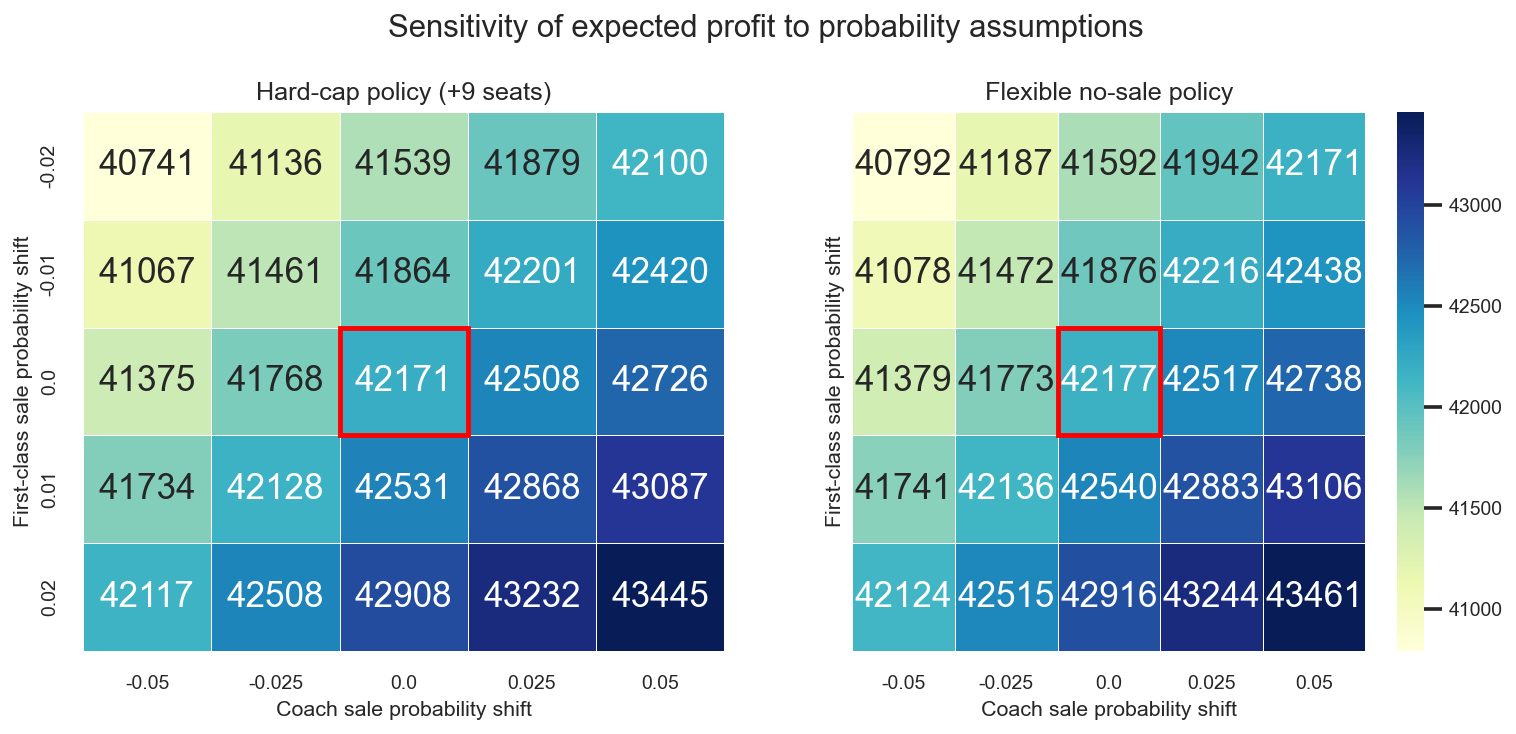

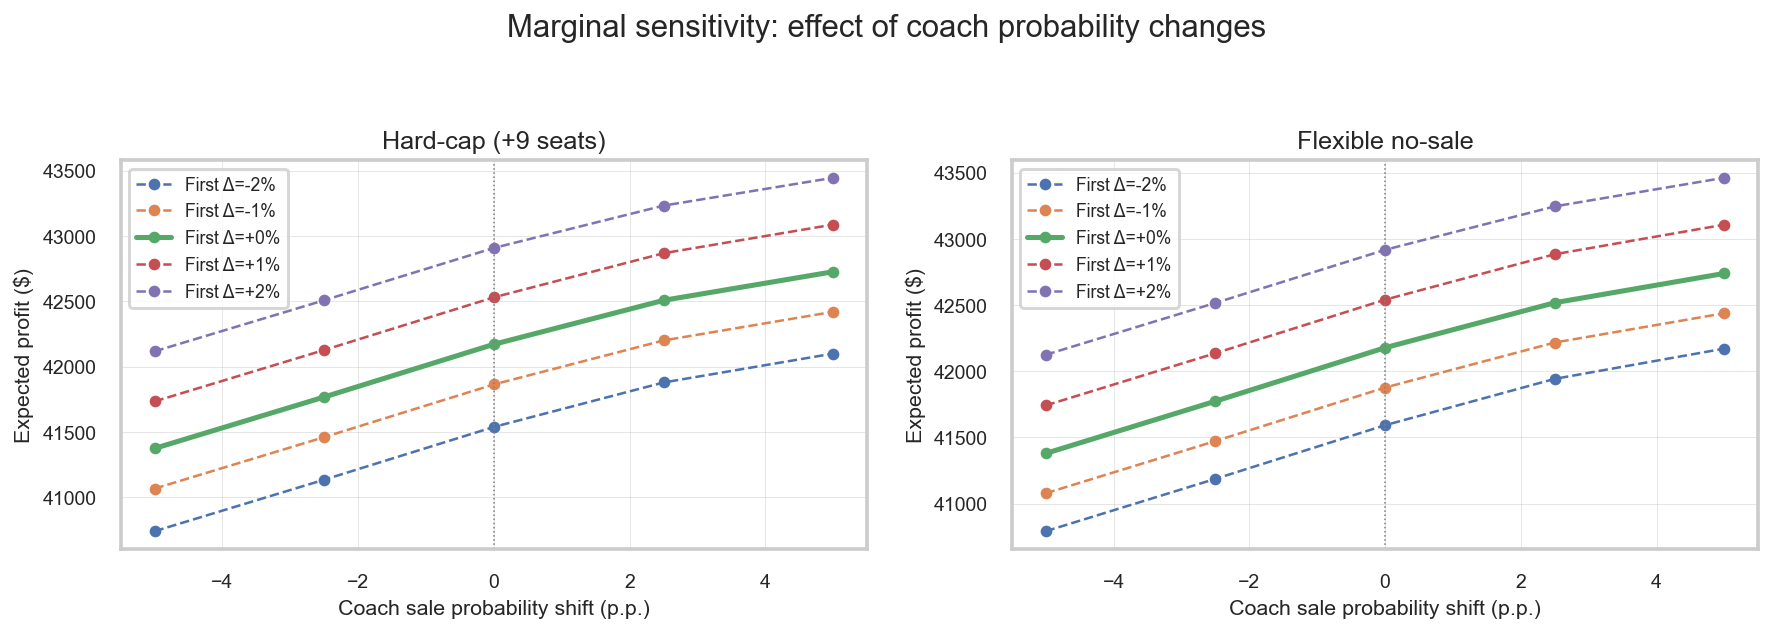

Hard-cap range: **$40,741.32** — **$43,445.13**.  Flexible range: **$40,791.58** — **$43,460.61**.

In [104]:
coach_delta_grid = np.array([-0.05, -0.025, 0.0, 0.025, 0.05])
first_delta_grid  = np.array([-0.02, -0.01,  0.0, 0.01,  0.02])

sens_hard = evaluate_sensitivity(100 + base_best_k, COACH_ACTIONS_FULL, coach_delta_grid, first_delta_grid)
sens_flex = evaluate_sensitivity(130,                COACH_ACTIONS_FLEX,  coach_delta_grid, first_delta_grid)

sens_hard.to_csv(TAB_DIR / 'sensitivity_hard_cap.csv',  index=False)
sens_flex.to_csv(TAB_DIR / 'sensitivity_flexible.csv', index=False)

# ── Visual 1: 2-D sensitivity heatmaps ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in [
    (axes[0], sens_hard, f'Hard-cap policy (+{base_best_k} seats)'),
    (axes[1], sens_flex,  'Flexible no-sale policy'),
]:
    heat = df.pivot(index='first_delta', columns='coach_delta', values='expected_profit')
    sns.heatmap(heat, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
                cbar=(ax is axes[1]), linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('Coach sale probability shift')
    ax.set_ylabel('First-class sale probability shift')
    # highlight the baseline (0, 0) cell
    zero_c = list(heat.columns).index(0.0)
    zero_r = list(heat.index).index(0.0)
    ax.add_patch(plt.Rectangle((zero_c, zero_r), 1, 1, fill=False, edgecolor='red', lw=2.5))

fig.suptitle('Sensitivity of expected profit to probability assumptions', y=1.02)
fig.savefig(FIG_DIR / 'sensitivity_heatmaps.png')
plt.show()

# ── Visual 2: marginal 1-D sensitivity — coach probability axis ──────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, df, title in [
    (axes2[0], sens_hard, f'Hard-cap (+{base_best_k} seats)'),
    (axes2[1], sens_flex,  'Flexible no-sale'),
]:
    for fd in first_delta_grid:
        subset = df[df['first_delta'] == fd].sort_values('coach_delta')
        lbl = f'First Δ={fd:+.0%}'
        lw  = 2.6 if fd == 0.0 else 1.3
        ls  = '-'  if fd == 0.0 else '--'
        ax.plot(subset['coach_delta'] * 100, subset['expected_profit'],
                marker='o', markersize=5, linewidth=lw, linestyle=ls, label=lbl)
    ax.axvline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(title)
    ax.set_xlabel('Coach sale probability shift (p.p.)')
    ax.set_ylabel('Expected profit ($)')
    ax.legend(fontsize=9, frameon=True)

fig2.suptitle('Marginal sensitivity: effect of coach probability changes', y=1.02)
fig2.tight_layout()
fig2.savefig(FIG_DIR / 'sensitivity_marginal.png')
plt.show()

display(Markdown(
    f"Hard-cap range: **${sens_hard['expected_profit'].min():,.2f}** — **${sens_hard['expected_profit'].max():,.2f}**.  "
    f"Flexible range: **${sens_flex['expected_profit'].min():,.2f}** — **${sens_flex['expected_profit'].max():,.2f}**."
))


## Parts 5 and 6: seasonal demand and forward simulation

Now sale probabilities are multiplied by `0.75 + t / 730`, where `t` is the booking-day index. After solving the seasonal dynamic programs, I simulate the best hard-cap rule and the flexible no-sale policy forward 100,000 times.

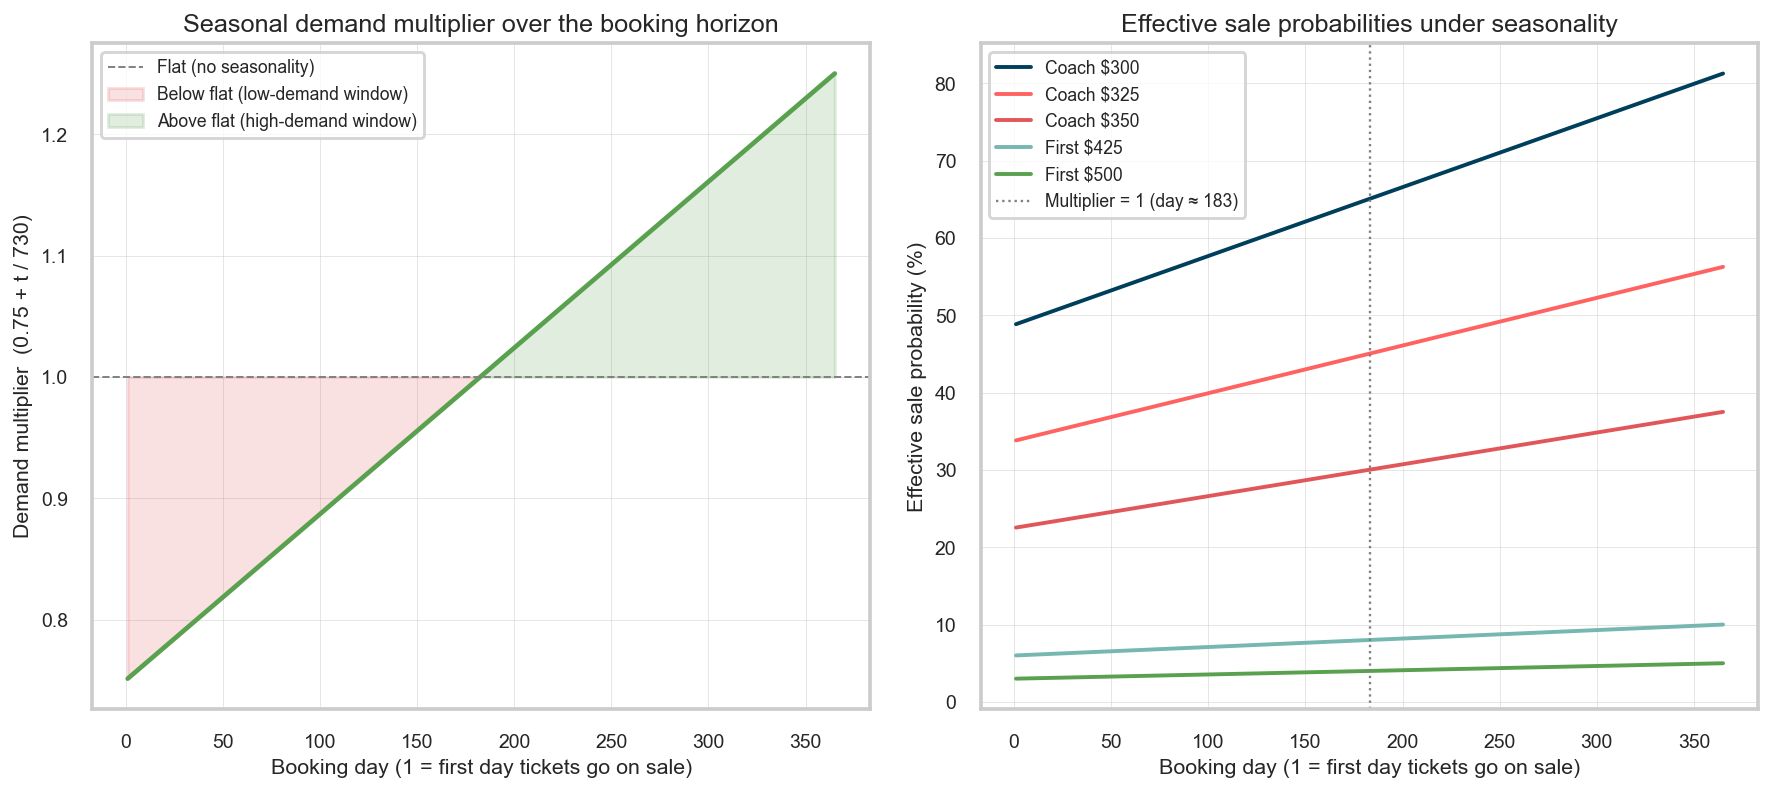

In [105]:
# ── Seasonality demand profile visualization ────────────────────────────────
# Show how the demand multiplier 0.75 + t/730 evolves over the 365-day horizon
# and what it does to each effective sale probability.

days_axis   = np.arange(1, DAYS + 1)
multipliers = 0.75 + days_axis / 730

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: multiplier curve
axes[0].plot(days_axis, multipliers, color='#59a14f', linewidth=2.4)
axes[0].axhline(1.0, color='grey', linestyle='--', linewidth=1, label='Flat (no seasonality)')
axes[0].fill_between(days_axis, multipliers, 1.0,
                     where=multipliers < 1, alpha=0.18, color='#e15759', label='Below flat (low-demand window)')
axes[0].fill_between(days_axis, multipliers, 1.0,
                     where=multipliers >= 1, alpha=0.18, color='#59a14f', label='Above flat (high-demand window)')
axes[0].set_xlabel('Booking day (1 = first day tickets go on sale)')
axes[0].set_ylabel('Demand multiplier  (0.75 + t / 730)')
axes[0].set_title('Seasonal demand multiplier over the booking horizon')
axes[0].legend(fontsize=9, frameon=True)

# Right: effective sale probabilities for each coach and first-class price
color_map = {'Coach $300': CLR_HARD, 'Coach $325': CLR_FLEX,
             'Coach $350': '#e15759', 'First $425': '#76b7b2', 'First $500': '#59a14f'}
for action in COACH_ACTIONS_FULL + FIRST_ACTIONS:
    eff_prob = np.minimum(action.prob * multipliers, 1.0)
    axes[1].plot(days_axis, eff_prob * 100, linewidth=2,
                 label=action.name, color=color_map[action.name])

axes[1].axvline(days_axis[multipliers >= 1][0], color='grey', linestyle=':', linewidth=1.2,
                label=f'Multiplier = 1 (day ≈ {days_axis[multipliers >= 1][0]})')
axes[1].set_xlabel('Booking day (1 = first day tickets go on sale)')
axes[1].set_ylabel('Effective sale probability (%)')
axes[1].set_title('Effective sale probabilities under seasonality')
axes[1].legend(fontsize=9, frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / 'seasonality_profile.png')
plt.show()


,Hard-cap,Flexible
policy,Seasonal hard-cap policy,Seasonal flexible no-sale policy
Exact DP value,41871.012506,41876.968821
Simulated mean discounted profit,41867.816149,41874.356998
Profit volatility (std),901.559575,907.671414
5th percentile profit,40368.719052,40364.453802
Median profit,41876.16318,41884.115655
95th percentile profit,43356.022275,43367.342308
Mean overbooking cost,1042.084,1085.643
Mean coach tickets sold,108.39208,108.59286
Mean first-class tickets sold,19.59771,19.53483


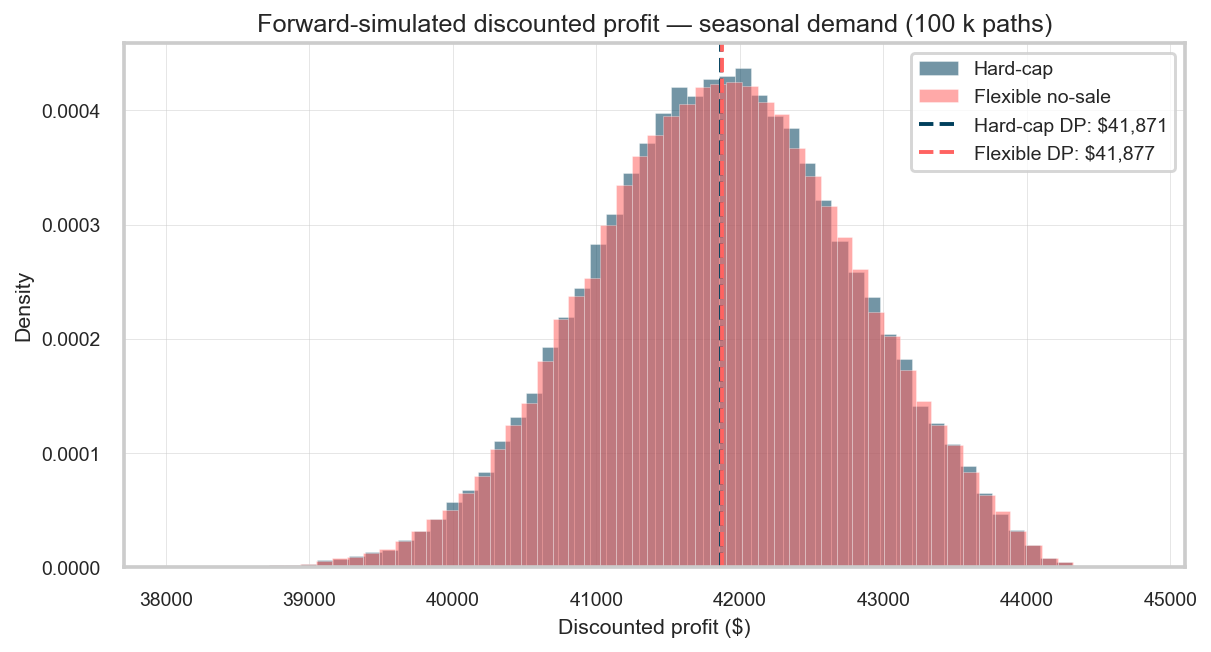

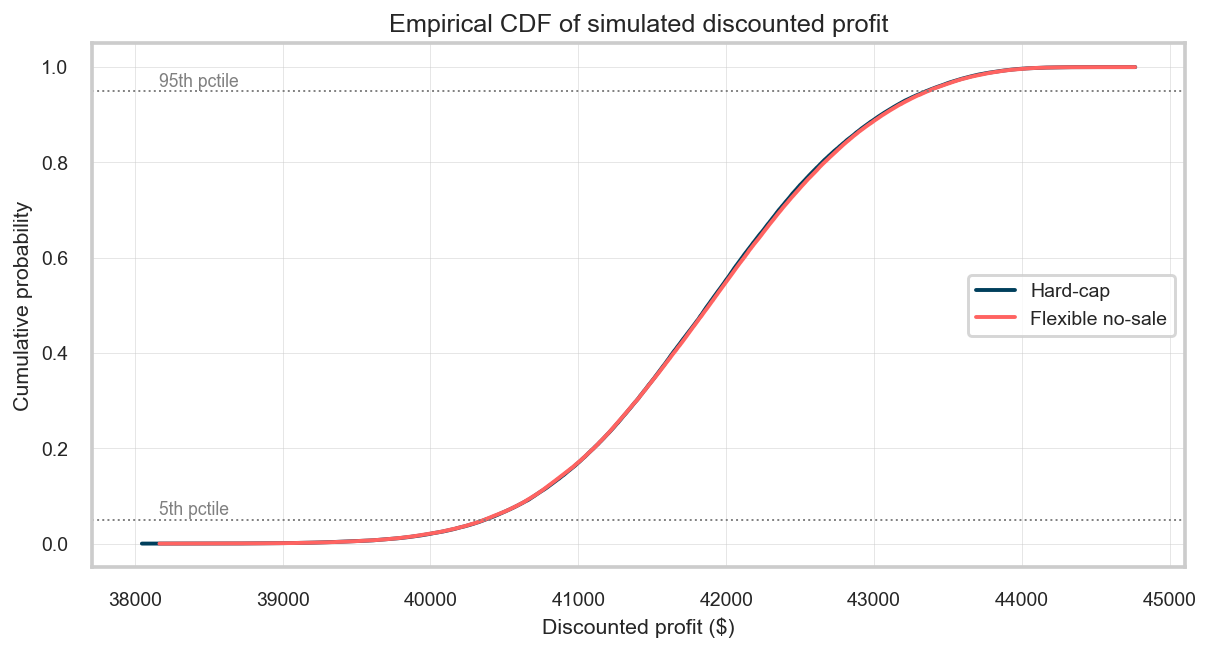

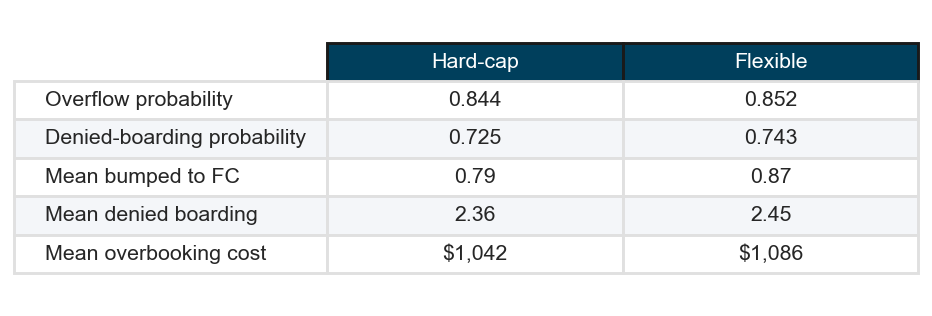

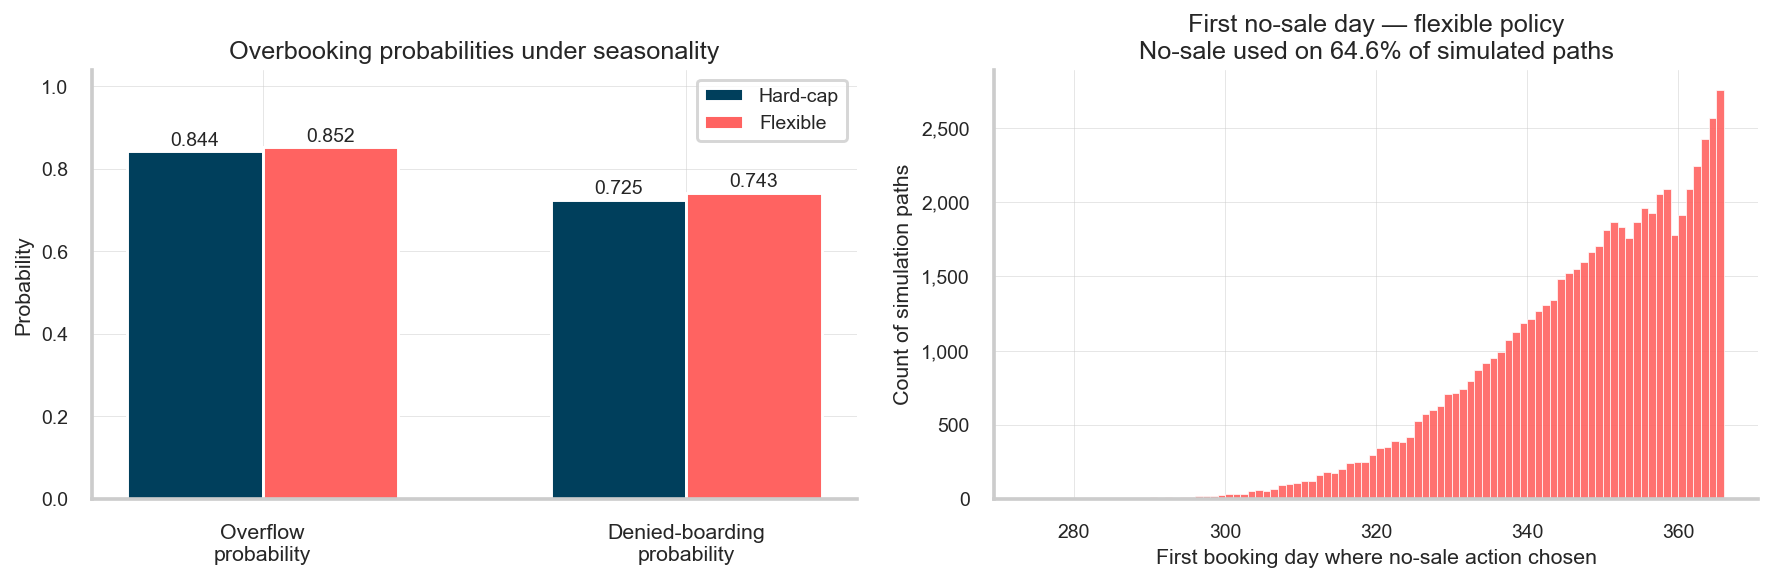

### Key simulation statistics

,Hard-cap,Flexible
Exact DP value,41871.0125,41876.9688
Simulated mean discounted profit,41867.8161,41874.3570
Profit volatility (std),901.5596,907.6714
5th percentile profit,40368.7191,40364.4538
95th percentile profit,43356.0223,43367.3423
Mean overbooking cost,1042.0840,1085.6430
Probability realized coach overflow occurs,0.8437,0.8524
Probability at least one passenger is denied boarding,0.7253,0.7425
Share of paths where no-sale action is used,0.0000,0.6464


In [106]:
seasonal_best_hard = solve_dp(100 + seasonal_best_k, COACH_ACTIONS_FULL, seasonality=True)
seasonal_flex      = solve_dp(130,                   COACH_ACTIONS_FLEX,  seasonality=True)

seasonal_hard_sim = simulate_policy(seasonal_best_hard, n_sim=SIM_N, seed=SIM_SEED)
seasonal_flex_sim = simulate_policy(seasonal_flex,       n_sim=SIM_N, seed=SIM_SEED)

simulation_summary_df = pd.DataFrame([
    {'policy': 'Seasonal hard-cap policy',         **seasonal_hard_sim['summary']},
    {'policy': 'Seasonal flexible no-sale policy', **seasonal_flex_sim['summary']},
])
simulation_summary_df.to_csv(TAB_DIR / 'seasonal_simulation_summary.csv', index=False)
display(simulation_summary_df.T.rename(columns={0: 'Hard-cap', 1: 'Flexible'}).round(4))

# ── Visual 1: overlaid profit density histograms ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(seasonal_hard_sim['discounted_profit'], bins=60, alpha=0.55, density=True,
        label='Hard-cap', color=CLR_HARD, edgecolor='white', linewidth=0.3)
ax.hist(seasonal_flex_sim['discounted_profit'], bins=60, alpha=0.55, density=True,
        label='Flexible no-sale', color=CLR_FLEX, edgecolor='white', linewidth=0.3)
ax.axvline(seasonal_best_hard['initial_value'], color=CLR_HARD, linestyle='--', linewidth=2,
           label=f"Hard-cap DP: ${seasonal_best_hard['initial_value']:,.0f}")
ax.axvline(seasonal_flex['initial_value'],      color=CLR_FLEX, linestyle='--', linewidth=2,
           label=f"Flexible DP: ${seasonal_flex['initial_value']:,.0f}")
ax.set_title('Forward-simulated discounted profit — seasonal demand (100 k paths)')
ax.set_xlabel('Discounted profit ($)')
ax.set_ylabel('Density')
ax.legend(fontsize=10, frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / 'seasonal_profit_hist.png')
plt.show()

# ── Visual 2: empirical CDFs ─────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
for profits, label, color in [
    (seasonal_hard_sim['discounted_profit'], 'Hard-cap',       CLR_HARD),
    (seasonal_flex_sim['discounted_profit'], 'Flexible no-sale', CLR_FLEX),
]:
    sorted_p = np.sort(profits)
    cdf      = np.arange(1, len(sorted_p) + 1) / len(sorted_p)
    ax2.plot(sorted_p, cdf, linewidth=2, label=label, color=color)
ax2.axhline(0.05, color='grey', linestyle=':', linewidth=1)
ax2.axhline(0.95, color='grey', linestyle=':', linewidth=1)
ax2.text(sorted_p[0], 0.06, '5th pctile', fontsize=9, color='grey')
ax2.text(sorted_p[0], 0.96, '95th pctile', fontsize=9, color='grey')
ax2.set_title('Empirical CDF of simulated discounted profit')
ax2.set_xlabel('Discounted profit ($)')
ax2.set_ylabel('Cumulative probability')
ax2.legend(fontsize=10, frameon=True)
fig2.tight_layout()
fig2.savefig(FIG_DIR / 'seasonal_profit_cdf.png')
plt.show()

# ── Chart 1: operational metrics summary table ────────────────────────────────
metrics_table = {
    'Overflow probability':          ('Probability realized coach overflow occurs',            '{:.3f}'),
    'Denied-boarding probability':   ('Probability at least one passenger is denied boarding', '{:.3f}'),
    'Mean bumped to FC':             ('Mean passengers upgraded to first class',               '{:.2f}'),
    'Mean denied boarding':          ('Mean passengers denied boarding',                       '{:.2f}'),
    'Mean overbooking cost':         ('Mean overbooking cost',                                 '${:,.0f}'),
}

rows = []
for label, (key, fmt) in metrics_table.items():
    h = seasonal_hard_sim['summary'][key]
    f = seasonal_flex_sim['summary'][key]
    rows.append({'Metric': label, 'Hard-cap': fmt.format(h), 'Flexible': fmt.format(f)})

table_df = pd.DataFrame(rows).set_index('Metric')

fig1, ax1 = plt.subplots(figsize=(7, 2.6))
ax1.axis('off')
tbl = ax1.table(
    cellText=table_df.values,
    rowLabels=table_df.index,
    colLabels=table_df.columns,
    cellLoc='center', rowLoc='left', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

# Header row styling
for col in range(len(table_df.columns)):
    tbl[(0, col)].set_facecolor(CLR_HARD)
    tbl[(0, col)].set_text_props(color='white', fontweight='500')

# Alternating row shading
for row in range(1, len(table_df) + 1):
    bg = '#f4f6f9' if row % 2 == 0 else 'white'
    for col in range(-1, len(table_df.columns)):
        tbl[(row, col)].set_facecolor(bg)
        tbl[(row, col)].set_edgecolor('#e0e0e0')

fig1.tight_layout()
fig1.savefig(FIG_DIR / 'seasonal_metrics_table.png')
plt.show()

# ── Visual 2 & 3: probability comparison bar + first no-sale day histogram ─────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overflow and denied-boarding probabilities side by side
prob_labels = ['Overflow\nprobability', 'Denied-boarding\nprobability']
prob_keys   = ['Probability realized coach overflow occurs',
               'Probability at least one passenger is denied boarding']
x = np.arange(len(prob_labels))
w = 0.32

hard_vals = [seasonal_hard_sim['summary'][k] for k in prob_keys]
flex_vals  = [seasonal_flex_sim['summary'][k]  for k in prob_keys]

b1 = axes2[0].bar(x - w/2, hard_vals, width=w, color=CLR_HARD, label='Hard-cap',  edgecolor='white')
b2 = axes2[0].bar(x + w/2, flex_vals,  width=w, color=CLR_FLEX, label='Flexible', edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        axes2[0].text(bar.get_x() + bar.get_width() / 2,
                      bar.get_height() + 0.004,
                      f'{bar.get_height():.3f}',
                      ha='center', va='bottom', fontsize=10)

axes2[0].set_xticks(x)
axes2[0].set_xticklabels(prob_labels, fontsize=11)
axes2[0].set_ylabel('Probability')
axes2[0].set_ylim(0, max(hard_vals + flex_vals) * 1.22)
axes2[0].legend(frameon=True, fontsize=10)
axes2[0].set_title('Overbooking probabilities under seasonality')
sns.despine(ax=axes2[0])

# Right: first no-sale day histogram
stop_days   = seasonal_flex_sim['stop_day']
finite_mask = np.isfinite(stop_days)
pct_used    = 100 * finite_mask.mean()

axes2[1].hist(stop_days[finite_mask],
              bins=range(int(stop_days[finite_mask].min()), 367),
              color=CLR_FLEX, edgecolor='white', linewidth=0.4, alpha=0.9)
axes2[1].set_xlabel('First booking day where no-sale action chosen')
axes2[1].set_ylabel('Count of simulation paths')
axes2[1].set_title(f'First no-sale day — flexible policy\n'
                   f'No-sale used on {pct_used:.1f}% of simulated paths')
axes2[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
sns.despine(ax=axes2[1])

fig2.tight_layout()
fig2.savefig(FIG_DIR / 'seasonal_diagnostics.png')
plt.show()



# ── Summary statistics table ──────────────────────────────────────────────────
display(Markdown("### Key simulation statistics"))
key_stats = ['Exact DP value', 'Simulated mean discounted profit', 'Profit volatility (std)',
             '5th percentile profit', '95th percentile profit', 'Mean overbooking cost',
             'Probability realized coach overflow occurs',
             'Probability at least one passenger is denied boarding',
             'Share of paths where no-sale action is used']
stats_df = pd.DataFrame({
    'Hard-cap':  {k: seasonal_hard_sim['summary'][k] for k in key_stats},
    'Flexible':  {k: seasonal_flex_sim['summary'][k]  for k in key_stats},
})
display(stats_df.round(4))


## Export summary and final recommendation

The next cell writes a compact `summary.json` file for the report and prints a concise recommendation.

In [107]:
summary_payload = {
    'step1_profit_k5':             step1_profit,
    'best_base_hard_k':            base_best_k,
    'best_base_hard_profit':       base_best_hard['initial_value'],
    'base_flex_profit':            base_flex['initial_value'],
    'best_seasonal_hard_k':        seasonal_best_k,
    'best_seasonal_hard_profit':   seasonal_best_hard['initial_value'],
    'seasonal_flex_profit':        seasonal_flex['initial_value'],
    'seasonal_hard_sim':           seasonal_hard_sim['summary'],
    'seasonal_flex_sim':           seasonal_flex_sim['summary'],
}
(OUTPUT_DIR / 'summary.json').write_text(json.dumps(summary_payload, indent=2))

diff_base     = base_flex['initial_value'] - base_best_hard['initial_value']
diff_seasonal = seasonal_flex['initial_value'] - seasonal_best_hard['initial_value']

display(Markdown(
    f"### Final Recommendation\n\n"
    f"**Parts 1–2 (hard-cap search)**\n"
    f"- Step 1 answer (5-seat oversell): **${step1_profit:,.2f}**\n"
    f"- Best baseline hard cap: overbook coach by **{base_best_k}** seats "
    f"(profit **${base_best_hard['initial_value']:,.2f}**)\n\n"
    f"**Part 3 (flexible no-sale)**\n"
    f"- Flexible policy (4 choices: $300 / $325 / $350 / no sale, cap 130): "
    f"**${base_flex['initial_value']:,.2f}** — "
    f"**${abs(diff_base):,.2f}** {'above' if diff_base >= 0 else 'below'} the best hard-cap rule.\n\n"
    f"**Parts 5–6 (seasonality + simulation)**\n"
    f"- Best seasonal hard cap: **{seasonal_best_k}** seats "
    f"(DP value **${seasonal_best_hard['initial_value']:,.2f}**)\n"
    f"- Seasonal flexible policy DP value: **${seasonal_flex['initial_value']:,.2f}** — "
    f"**${abs(diff_seasonal):,.2f}** {'above' if diff_seasonal >= 0 else 'below'} the seasonal hard cap.\n"
    f"- Simulated mean profit (hard-cap): **${seasonal_hard_sim['summary']['Simulated mean discounted profit']:,.2f}** "
    f"± ${seasonal_hard_sim['summary']['Profit volatility (std)']:,.2f}\n"
    f"- Simulated mean profit (flexible): **${seasonal_flex_sim['summary']['Simulated mean discounted profit']:,.2f}** "
    f"± ${seasonal_flex_sim['summary']['Profit volatility (std)']:,.2f}"
))

summary_payload


### Final Recommendation

**Parts 1–2 (hard-cap search)**
- Step 1 answer (5-seat oversell): **$41,909.75**
- Best baseline hard cap: overbook coach by **9** seats (profit **$42,171.35**)

**Part 3 (flexible no-sale)**
- Flexible policy (4 choices: $300 / $325 / $350 / no sale, cap 130): **$42,177.14** — **$5.79** above the best hard-cap rule.

**Parts 5–6 (seasonality + simulation)**
- Best seasonal hard cap: **9** seats (DP value **$41,871.01**)
- Seasonal flexible policy DP value: **$41,876.97** — **$5.96** above the seasonal hard cap.
- Simulated mean profit (hard-cap): **$41,867.82** ± $901.56
- Simulated mean profit (flexible): **$41,874.36** ± $907.67

{'step1_profit_k5': 41909.748481378054,
 'best_base_hard_k': 9,
 'best_base_hard_profit': 42171.34699809325,
 'base_flex_profit': 42177.136612522336,
 'best_seasonal_hard_k': 9,
 'best_seasonal_hard_profit': 41871.01250574179,
 'seasonal_flex_profit': 41876.968820752976,
 'seasonal_hard_sim': {'Exact DP value': 41871.01250574179,
  'Simulated mean discounted profit': 41867.816149189326,
  'Profit volatility (std)': 901.5595753776283,
  '5th percentile profit': 40368.71905184342,
  'Median profit': 41876.163179773706,
  '95th percentile profit': 43356.02227483016,
  'Mean overbooking cost': 1042.084,
  'Mean coach tickets sold': 108.39208,
  'Mean first-class tickets sold': 19.59771,
  'Probability coach is oversold in bookings': 1.0,
  'Probability realized coach overflow occurs': 0.84368,
  'Probability at least one passenger is denied boarding': 0.72529,
  'Mean passengers upgraded to first class': 0.78542,
  'Mean passengers denied boarding': 2.35956,
  'Share of paths where no-sale